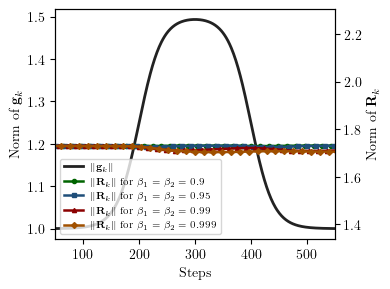

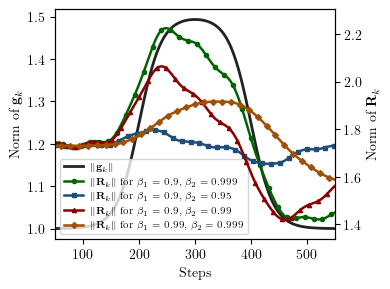

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Estilo sobrio con LaTeX
plt.style.use("default")
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

def sigmoid(x: float) -> float:
    return 1.0 / (1.0 + np.exp(-x))

# --- Gradiente ficticio con meseta via 2 sigmoides ---------------------------
def scale_fn(t: float) -> float:
    """
    Construye una escala suave usando la diferencia de dos sigmoides:
    - ~1 en [0, 150]
    - subida suave en [150, 250]
    - ~1.5 en [250, 350]
    - bajada suave en [350, 450]
    - ~1 en [450, 600]
    """
    mu_up = 200.0   # centro de la subida
    mu_down = 400.0 # centro de la bajada
    width = 20.0    # controla lo ancha que es la transición

    s_up = sigmoid((t - mu_up) / width)
    s_down = sigmoid((t - mu_down) / width)

    scale = 1 + 0.5 * (s_up - s_down)
    return scale

def gradient(t: float) -> np.ndarray:
    """
    Dirección oscilante, ligeramente variable en el tiempo.
    La norma sigue scale_fn(t).
    """
    base = np.array([
        10.0,
        -8.0 + np.sin(t / 10.0),
        9.0 + np.cos(t / 10.0)
    ], dtype=float)

    base = base / np.linalg.norm(base)  # normalizamos la dirección
    scale = scale_fn(t)
    return scale * base

# Tiempo y gradientes
t_max = 600
times = np.arange(0, t_max + 1, dtype=float)
grads = np.stack([gradient(t) for t in times], axis=0)

# Norma del gradiente: ||g_k||
s_t = np.linalg.norm(grads, axis=1)

# --- Parámetros Adam (lr y eps fijos) ----------------------------------------
lr = 1e-3
eps = 1e-8

def adam_R(grads: np.ndarray, beta1: float, beta2: float,
           lr: float = 1e-3, eps: float = 1e-8) -> np.ndarray:
    """
    Devuelve la secuencia R_k de Adam (con bias correction)
    para una pareja (beta1, beta2).
    """
    T, d = grads.shape
    m = np.zeros((T, d), dtype=float)
    v = np.zeros((T, d), dtype=float)
    R = np.zeros((T, d), dtype=float)

    for k in range(1, T):
        t_idx = k  # para bias correction
        g_t = grads[k]

        m[k] = beta1 * m[k - 1] + (1.0 - beta1) * g_t
        v[k] = beta2 * v[k - 1] + (1.0 - beta2) * (g_t ** 2)

        m_hat = m[k] / (1.0 - beta1 ** t_idx)
        v_hat = v[k] / (1.0 - beta2 ** t_idx)

        R[k] = m_hat / (np.sqrt(v_hat) + eps)

    return R

# --- Precomputar todas las normas ||R_k|| para fijar escala común ------------
equal_betas = [0.9, 0.95, 0.99, 0.999]
unequal_betas = [
    (0.9, 0.999),
    (0.9, 0.95),
    (0.9, 0.99),
    (0.99, 0.999),
]

all_R_norms = []

R_equal_dict = {}
for beta in equal_betas:
    R = adam_R(grads, beta1=beta, beta2=beta, lr=lr, eps=eps)
    norm_R = np.linalg.norm(R, axis=1)
    R_equal_dict[beta] = norm_R
    all_R_norms.append(norm_R[1:])  # ignoramos k=0 para no forzar min=0 en la escala

R_unequal_dict = {}
for beta1, beta2 in unequal_betas:
    R = adam_R(grads, beta1=beta1, beta2=beta2, lr=lr, eps=eps)
    norm_R = np.linalg.norm(R, axis=1)
    R_unequal_dict[(beta1, beta2)] = norm_R
    all_R_norms.append(norm_R[1:])  # idem

all_R_norms = np.concatenate(all_R_norms)
R_min_raw = np.min(all_R_norms)
R_max_raw = np.max(all_R_norms)
span_R = R_max_raw - R_min_raw

if span_R == 0:
    span_R = max(1.0, R_max_raw)

# Margen del 10 % arriba y abajo, sin bajar de 0
R_ymin = max(0.0, R_min_raw - 0.1 * span_R)
R_ymax = R_max_raw + 0.1 * span_R

# Paleta de colores sobrios
grad_color = "#222222"  # casi negro para ||g_k||
color_list = [
    "#006400",  # verde oscuro
    "#1f4e79",  # azul oscuro
    "#8b0000",  # rojo oscuro
    "#a05000",  # naranja oscuro
]
marker_list = ["o", "s", "^", "D"]  # 4 tipos de marcadores

# --- Figura 1: beta1 = beta2 -------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(4, 3))

# ||g_k|| en línea continua, sin marcadores
line_g = ax1.plot(
    times, s_t,
    linestyle="-",
    linewidth=2.0,
    color=grad_color,
    label=r"$\|\mathbf{g}_k\|$"
)[0]

ax1.set_xlabel(r"Steps")
ax1.set_ylabel(r"Norm of $\mathbf{g}_k$")
ax1.set_xlim(50, 550)

ax2 = ax1.twinx()
ax2.set_ylabel(r"Norm of $\mathbf{R}_k$")
ax2.set_ylim(R_ymin, R_ymax)  # misma escala con margen

lines_fig1 = [line_g]

# Curvas de ||R_k|| para cada beta, con colores oscuros + marcadores desplazados
for i, beta in enumerate(equal_betas):
    norm_R = R_equal_dict[beta]
    color = color_list[i]
    marker = marker_list[i]
    offset = 4 * i  # 0, 4, 8, 12

    line_R = ax2.plot(
        times, norm_R,
        linewidth=1.8,
        color=color,
        marker=marker,
        markersize=3.0,
        markevery=(offset, 16),
        label=rf"$\|\mathbf{{R}}_k\|$ for $\beta_1 = \beta_2 = {beta}$"
    )[0]
    lines_fig1.append(line_R)

labels_fig1 = [line.get_label() for line in lines_fig1]
ax1.legend(lines_fig1, labels_fig1, loc="lower left", frameon=True, fontsize=7)

fig1.tight_layout()

# --- Figura 2: beta1 ≠ beta2 -------------------------------------------------
fig2, ax3 = plt.subplots(figsize=(4, 3))

# ||g_k|| en línea continua, sin marcadores
line_g2 = ax3.plot(
    times, s_t,
    linestyle="-",
    linewidth=2.0,
    color=grad_color,
    label=r"$\|\mathbf{g}_k\|$"
)[0]

ax3.set_xlabel(r"Steps")
ax3.set_ylabel(r"Norm of $\mathbf{g}_k$")
ax3.set_xlim(50, 550)

ax4 = ax3.twinx()
ax4.set_ylabel(r"Norm of $\mathbf{R}_k$")
ax4.set_ylim(R_ymin, R_ymax)  # misma escala con margen

lines_fig2 = [line_g2]

for i, (beta1, beta2) in enumerate(unequal_betas):
    norm_R = R_unequal_dict[(beta1, beta2)]
    color = color_list[i]
    marker = marker_list[i]
    offset = 4 * i  # 0, 4, 8, 12

    line_R2 = ax4.plot(
        times, norm_R,
        linewidth=1.8,
        color=color,
        marker=marker,
        markersize=3.0,
        markevery=(offset, 16),
        label=rf"$\|\mathbf{{R}}_k\|$ for $\beta_1 = {beta1},\,\beta_2 = {beta2}$"
    )[0]
    lines_fig2.append(line_R2)

labels_fig2 = [line.get_label() for line in lines_fig2]
ax3.legend(lines_fig2, labels_fig2, loc="lower left", frameon=True, fontsize=7)

fig2.tight_layout()

fig1.savefig("figure_equal_betas.pdf", bbox_inches="tight", dpi=300)
fig2.savefig("figure_unequal_betas.pdf", bbox_inches="tight", dpi=300)
